# NB-05 — Q-Former: The Smart Projector

**Goal:** Build Q-Former from scratch and understand why it's powerful.

**The key insight:** Q-Former doesn't just project features — it *selects* what information to pass to the LLM. It uses learned query vectors to ask targeted questions about the image.

**Background:**
- Linear projector: passes ALL patch tokens (196) to LLM → expensive
- MLP projector: same problem — still 196 tokens per image
- Q-Former: compresses to N learnable queries (e.g. 32) → cheaper, often better!

---

## 🧠 Concept: How Q-Former Works

```
Image Encoder Output          Learnable Query Tokens
[batch, 196, 1024]            [batch, 32, llm_dim]   ← these are PARAMETERS, not inputs!
        │                              │
        │         Cross-Attention      │
        └──────────────────────────────┘
                        │
              Queries attend to image patches
              (each query can focus on different regions)
                        │
              Self-Attention among queries
              (queries communicate with each other)
                        │
              Feed-Forward + LayerNorm
                        │
              [batch, 32, llm_dim]  ← fixed size regardless of image!
```

**Analogy:** Imagine you have a photo and 32 expert analysts. Each analyst asks a specific question about the photo ("What is in the foreground?", "What colors are dominant?", etc.). Their answers are what gets passed to the LLM — not the raw photo pixels.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional

DEVICE = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {DEVICE}")
DEVICE = "cpu"

Device: mps


## Step 1: Cross-Attention Module

The core mechanism: queries attend to the encoder output.

In [ ]:
class CrossAttention(nn.Module):
    """Queries (Q) attend to encoder output (K, V).
    
    Args:
        query_dim: Dimension of the query vectors.
        kv_dim: Dimension of the key/value vectors (encoder output dim).
        num_heads: Number of attention heads.
        dropout: Dropout probability.
    """
    
    def __init__(self, query_dim: int, kv_dim: int, num_heads: int, dropout: float = 0.0):
        super().__init__()
        assert query_dim % num_heads == 0, "query_dim must be divisible by num_heads"
        
        self.num_heads = num_heads
        self.head_dim = query_dim // num_heads
        self.scale = self.head_dim ** -0.5  # 1/sqrt(d_k) scaling
        
        # Queries come from the learnable queries (query_dim)
        self.q_proj = nn.Linear(query_dim, query_dim, bias=False)
        # Keys and values come from the image encoder (kv_dim → query_dim)
        self.k_proj = nn.Linear(kv_dim, query_dim, bias=False)
        self.v_proj = nn.Linear(kv_dim, query_dim, bias=False)
        self.out_proj = nn.Linear(query_dim, query_dim)
        self.dropout = nn.Dropout(dropout)
    
    def forward(
        self,
        queries: torch.Tensor,      # [B, num_queries, query_dim]
        encoder_output: torch.Tensor,  # [B, num_patches, kv_dim]
        return_attn_weights: bool = False,
    ) -> tuple[torch.Tensor, Optional[torch.Tensor]]:
        B, Nq, _ = queries.shape
        B, Nk, _ = encoder_output.shape
        
        # Project to Q, K, V
        Q = self.q_proj(queries)          # [B, Nq, query_dim]
        K = self.k_proj(encoder_output)   # [B, Nk, query_dim]
        V = self.v_proj(encoder_output)   # [B, Nk, query_dim]
        
        # Reshape for multi-head attention: [B, heads, seq, head_dim]
        Q = Q.view(B, Nq, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, Nk, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, Nk, self.num_heads, self.head_dim).transpose(1, 2)
        
        # Attention scores: Q @ K^T / sqrt(head_dim)
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale
        # Shape: [B, heads, Nq, Nk] — each query attending to each patch
        
        attn_weights = F.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        # Weighted sum of values
        out = torch.matmul(attn_weights, V)  # [B, heads, Nq, head_dim]
        out = out.transpose(1, 2).contiguous().view(B, Nq, -1)  # [B, Nq, query_dim]
        out = self.out_proj(out)
        
        if return_attn_weights:
            return out, attn_weights
        return out, None


# --- Quick test ---
QUERY_DIM = 256
KV_DIM = 1024   # typical CLIP output dim
NUM_QUERIES = 32
NUM_PATCHES = 196
BATCH = 2
NUM_HEADS = 8

cross_attn = CrossAttention(QUERY_DIM, KV_DIM, NUM_HEADS)
queries = torch.randn(BATCH, NUM_QUERIES, QUERY_DIM)
encoder_out = torch.randn(BATCH, NUM_PATCHES, KV_DIM)

out, weights = cross_attn(queries, encoder_out, return_attn_weights=True)

print("Cross-Attention shapes:")
print(f"  Input queries:   {queries.shape}  → [B, Nq, query_dim]")
print(f"  Encoder output:  {encoder_out.shape}  → [B, Nk, kv_dim]")
print(f"  Output:          {out.shape}  → [B, Nq, query_dim]  (same as queries)")
print(f"  Attn weights:    {weights.shape}  → [B, heads, Nq, Nk]")
print()
print("Each of the 32 queries now contains a weighted summary of the 196 image patches.")

Cross-Attention shapes:
  Input queries:   torch.Size([2, 32, 256])  → [B, Nq, query_dim]
  Encoder output:  torch.Size([2, 196, 1024])  → [B, Nk, kv_dim]
  Output:          torch.Size([2, 32, 256])  → [B, Nq, query_dim]  (same as queries)
  Attn weights:    torch.Size([2, 8, 32, 196])  → [B, heads, Nq, Nk]

Each of the 32 queries now contains a weighted summary of the 196 image patches.


## Step 2: Visualize Cross-Attention

Let's see what the attention matrix looks like — which patches each query attends to.

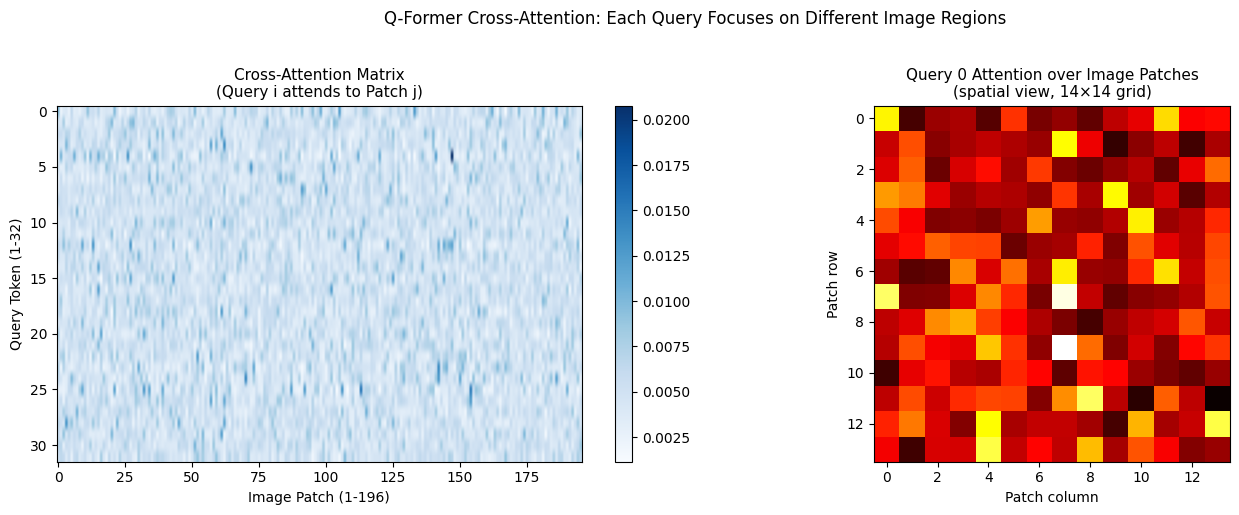

Note: With random weights (untrained), the pattern is random.
After training, each query learns to focus on semantically meaningful regions.


In [3]:
# Use the attention weights from above
# weights: [B=2, heads=8, Nq=32, Nk=196]

# Take first sample, first head
attn_sample = weights[0, 0].detach().numpy()  # [32, 196]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full attention matrix: 32 queries × 196 patches
im = axes[0].imshow(attn_sample, aspect='auto', cmap='Blues')
plt.colorbar(im, ax=axes[0])
axes[0].set_title("Cross-Attention Matrix\n(Query i attends to Patch j)", fontsize=11)
axes[0].set_xlabel("Image Patch (1-196)")
axes[0].set_ylabel("Query Token (1-32)")

# Show attention for query 0 as a spatial map (14×14 grid)
query_0_attn = attn_sample[0].reshape(14, 14)  # [14, 14]
axes[1].imshow(query_0_attn, cmap='hot', interpolation='nearest')
axes[1].set_title("Query 0 Attention over Image Patches\n(spatial view, 14×14 grid)", fontsize=11)
axes[1].set_xlabel("Patch column")
axes[1].set_ylabel("Patch row")

plt.suptitle("Q-Former Cross-Attention: Each Query Focuses on Different Image Regions",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("Note: With random weights (untrained), the pattern is random.")
print("After training, each query learns to focus on semantically meaningful regions.")

## Step 3: Full Q-Former Block

One full Q-Former layer = Cross-Attention + Self-Attention + Feed-Forward

In [4]:
class QFormerBlock(nn.Module):
    """Single Q-Former transformer block.
    
    Consists of:
    1. Cross-attention: queries attend to encoder output
    2. Self-attention: queries attend to each other  
    3. Feed-forward: per-query MLP
    
    Args:
        query_dim: Dimension of query vectors.
        kv_dim: Dimension of encoder key/value vectors.
        num_heads: Number of attention heads.
        ff_dim: Feed-forward hidden dimension.
        dropout: Dropout probability.
    """
    
    def __init__(
        self, query_dim: int, kv_dim: int, num_heads: int,
        ff_dim: int, dropout: float = 0.1
    ):
        super().__init__()
        
        # 1. Cross-attention: queries ← encoder
        self.cross_attn = CrossAttention(query_dim, kv_dim, num_heads, dropout)
        self.cross_attn_norm = nn.LayerNorm(query_dim)
        
        # 2. Self-attention: queries ← queries
        self.self_attn = nn.MultiheadAttention(
            embed_dim=query_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        self.self_attn_norm = nn.LayerNorm(query_dim)
        
        # 3. Feed-forward
        self.ff = nn.Sequential(
            nn.Linear(query_dim, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, query_dim),
            nn.Dropout(dropout),
        )
        self.ff_norm = nn.LayerNorm(query_dim)
    
    def forward(
        self,
        queries: torch.Tensor,          # [B, Nq, query_dim]
        encoder_output: torch.Tensor,   # [B, Nk, kv_dim]
    ) -> torch.Tensor:
        # 1. Cross-attention with residual
        ca_out, _ = self.cross_attn(queries, encoder_output)
        queries = self.cross_attn_norm(queries + ca_out)  # residual connection!
        
        # 2. Self-attention with residual
        sa_out, _ = self.self_attn(queries, queries, queries)
        queries = self.self_attn_norm(queries + sa_out)
        
        # 3. Feed-forward with residual
        ff_out = self.ff(queries)
        queries = self.ff_norm(queries + ff_out)
        
        return queries


# Test block
block = QFormerBlock(QUERY_DIM, KV_DIM, NUM_HEADS, ff_dim=QUERY_DIM * 4)
q_out = block(queries, encoder_out)
print(f"QFormerBlock output shape: {q_out.shape}")
print(f"  Input queries:  {queries.shape}")
print(f"  Output queries: {q_out.shape}  ← same shape, richer content")

QFormerBlock output shape: torch.Size([2, 32, 256])
  Input queries:  torch.Size([2, 32, 256])
  Output queries: torch.Size([2, 32, 256])  ← same shape, richer content


## Step 4: Full Q-Former Module

In [5]:
class QFormer(nn.Module):
    """Q-Former projector: compresses image features into fixed-size query tokens.
    
    The key difference from Linear/MLP projectors:
    - Output is ALWAYS [batch, num_queries, llm_dim] regardless of input sequence length
    - Learnable queries act as a bottleneck, selecting relevant information
    - Much more parameter-efficient when num_queries << num_patches
    
    Args:
        num_queries: Number of learnable query tokens (e.g. 32).
        encoder_dim: Dimension of vision encoder output (e.g. 1024 for CLIP ViT-L).
        llm_dim: Dimension expected by the LLM (e.g. 4096 for Qwen-7B).
        num_heads: Attention heads (must divide llm_dim).
        num_layers: Number of Q-Former blocks.
        dropout: Dropout probability.
    """
    
    def __init__(
        self,
        num_queries: int = 32,
        encoder_dim: int = 1024,
        llm_dim: int = 4096,
        num_heads: int = 8,
        num_layers: int = 6,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.num_queries = num_queries
        self.llm_dim = llm_dim
        
        # THE KEY: learnable query tokens — initialized randomly, trained end-to-end
        # These are NOT image patches; they're the "questions" we ask about the image
        self.queries = nn.Parameter(torch.randn(1, num_queries, llm_dim))
        nn.init.trunc_normal_(self.queries, std=0.02)  # stable initialization
        
        # Stack of Q-Former blocks
        self.layers = nn.ModuleList([
            QFormerBlock(llm_dim, encoder_dim, num_heads, ff_dim=llm_dim * 4, dropout=dropout)
            for _ in range(num_layers)
        ])
        
        # Final layer norm
        self.norm = nn.LayerNorm(llm_dim)
    
    def forward(self, encoder_output: torch.Tensor) -> torch.Tensor:
        """Compress encoder output into fixed-size query tokens.
        
        Args:
            encoder_output: Vision encoder features, shape [B, num_patches, encoder_dim].
            
        Returns:
            Query tokens, shape [B, num_queries, llm_dim].
            Always the same size regardless of input sequence length.
        """
        B = encoder_output.shape[0]
        
        # Expand learned queries for the batch
        queries = self.queries.expand(B, -1, -1)  # [B, num_queries, llm_dim]
        
        # Run through all Q-Former blocks
        for layer in self.layers:
            queries = layer(queries, encoder_output)
        
        return self.norm(queries)  # [B, num_queries, llm_dim]


# --- Test with different input sizes ---
qformer = QFormer(num_queries=32, encoder_dim=KV_DIM, llm_dim=QUERY_DIM, num_heads=NUM_HEADS, num_layers=2)

print("Q-Former shape test — output is FIXED regardless of input size:")
for num_patches in [196, 256, 576]:  # different image resolutions
    enc_out = torch.randn(2, num_patches, KV_DIM)
    result = qformer(enc_out)
    print(f"  Input: [2, {num_patches}, {KV_DIM}] → Output: {result.shape}")

print()
trainable = sum(p.numel() for p in qformer.parameters() if p.requires_grad)
print(f"Q-Former trainable parameters: {trainable:,}")
print(f"  (of which learnable queries: {qformer.queries.numel():,})")

Q-Former shape test — output is FIXED regardless of input size:
  Input: [2, 196, 1024] → Output: torch.Size([2, 32, 256])
  Input: [2, 256, 1024] → Output: torch.Size([2, 32, 256])
  Input: [2, 576, 1024] → Output: torch.Size([2, 32, 256])

Q-Former trainable parameters: 2,900,480
  (of which learnable queries: 8,192)


## Step 5: Projector Comparison

Linear vs MLP vs Q-Former — tradeoffs at a glance.

In [6]:
ENCODER_DIM = 1024
LLM_DIM = 4096
NUM_PATCHES = 196
NUM_QUERIES = 32
BATCH = 1

enc_output = torch.randn(BATCH, NUM_PATCHES, ENCODER_DIM)

# Linear projector
linear = nn.Linear(ENCODER_DIM, LLM_DIM)
linear_out = linear(enc_output)

# MLP projector
mlp = nn.Sequential(
    nn.Linear(ENCODER_DIM, ENCODER_DIM * 2), nn.GELU(),
    nn.Linear(ENCODER_DIM * 2, LLM_DIM)
)
mlp_out = mlp(enc_output)

# Q-Former
qf = QFormer(num_queries=NUM_QUERIES, encoder_dim=ENCODER_DIM, 
             llm_dim=LLM_DIM, num_heads=8, num_layers=3)
qf_out = qf(enc_output)

print("=" * 60)
print(f"{'Projector':<12} {'Output Shape':<22} {'LLM Tokens':<12} {'Params':>10}")
print("=" * 60)

linear_params = sum(p.numel() for p in linear.parameters())
mlp_params = sum(p.numel() for p in mlp.parameters())
qf_params = sum(p.numel() for p in qf.parameters())

print(f"{'Linear':<12} {str(linear_out.shape):<22} {NUM_PATCHES:<12} {linear_params:>10,}")
print(f"{'MLP':<12} {str(mlp_out.shape):<22} {NUM_PATCHES:<12} {mlp_params:>10,}")
print(f"{'Q-Former':<12} {str(qf_out.shape):<22} {NUM_QUERIES:<12} {qf_params:>10,}")
print("=" * 60)
print()
print("Key insight:")
print(f"  Linear/MLP pass {NUM_PATCHES} tokens to LLM per image")
print(f"  Q-Former passes only {NUM_QUERIES} tokens per image")
print(f"  Token reduction: {NUM_PATCHES/NUM_QUERIES:.1f}x fewer tokens!")
print()
print("This matters because LLM context window is limited.")
print(f"With a 2048 token context: {2048 // NUM_PATCHES} images (MLP) vs {2048 // NUM_QUERIES} images (Q-Former)")

Projector    Output Shape           LLM Tokens       Params
Linear       torch.Size([1, 196, 4096]) 196           4,198,400
MLP          torch.Size([1, 196, 4096]) 196          10,491,904
Q-Former     torch.Size([1, 32, 4096]) 32           730,144,768

Key insight:
  Linear/MLP pass 196 tokens to LLM per image
  Q-Former passes only 32 tokens per image
  Token reduction: 6.1x fewer tokens!

This matters because LLM context window is limited.
With a 2048 token context: 10 images (MLP) vs 64 images (Q-Former)


In [7]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

from src.projectors.qformer import QFormer as ProductionQFormer

prod_qf = ProductionQFormer(
    num_queries=32,
    encoder_dim=KV_DIM,
    llm_dim=4096,
    num_heads=8,
    num_layers=2,
)
enc = torch.randn(2, 196, KV_DIM)
out, attn = prod_qf(enc, return_cross_attn=True)
print(f"Production QFormer output: {out.shape}")
print(f"Cross-attention weights:   {attn.shape}")

Production QFormer output: torch.Size([2, 32, 4096])
Cross-attention weights:   torch.Size([2, 32, 196])


## ✅ Phase 2 (Q-Former) Checklist

- [ ] I understand why Q-Former compresses to a fixed number of tokens
- [ ] I can explain what the learnable query vectors are (NOT image patches)
- [ ] I understand cross-attention: queries ask questions, encoder output answers them
- [ ] I can explain the token budget tradeoff between the three projectors
- [ ] `QFormer` in `src/projectors/qformer.py` is tested

**Next:** Phase 3 — `NB-06-llm-backbone.ipynb`

## ✅ Phase 2 (Q-Former) Checklist

- [ ] I understand why Q-Former compresses to a fixed number of tokens
- [ ] I can explain what the learnable query vectors are (NOT image patches)
- [ ] I understand cross-attention: queries ask questions, encoder output answers them
- [ ] I can explain the token budget tradeoff between the three projectors
- [ ] `QFormer` class built and tested

**Next:** Open `NB-06-llm-backbone.ipynb` — connect everything to a real LLM!

Copy `QFormer` to `src/projectors/qformer.py` and add tests.